# **Projet AI — Resume Screening & Job Matching**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/ResumeProject"
os.makedirs(project_path, exist_ok=True)
os.makedirs(f"{project_path}/models", exist_ok=True)
print("✅ Dossiers prêts")

✅ Dossiers prêts


**PHASE 1 — Préparation des données**

**Étape 1 : Collecter le dataset de CVs**

In [ ]:
import pandas as pd
dataset_path = "/content/drive/MyDrive/ResumeProject/Resume.csv"
df = pd.read_csv(dataset_path)
print(df.head())
print("Nombre de lignes :", len(df))

         ID                                         Resume_str  \
0  16852973           HR ADMINISTRATOR/MARKETING ASSOCIATE\...   
1  22323967           HR SPECIALIST, US HR OPERATIONS      ...   
2  33176873           HR DIRECTOR       Summary      Over 2...   
3  27018550           HR SPECIALIST       Summary    Dedica...   
4  17812897           HR MANAGER         Skill Highlights  ...   

                                         Resume_html Category  
0  <div class="fontsize fontface vmargins hmargin...       HR  
1  <div class="fontsize fontface vmargins hmargin...       HR  
2  <div class="fontsize fontface vmargins hmargin...       HR  
3  <div class="fontsize fontface vmargins hmargin...       HR  
4  <div class="fontsize fontface vmargins hmargin...       HR  
Nombre de lignes : 2484


**Étape 2 : Collecter les offres d'emploi**

In [ ]:
# CREATION DU DATASET DE JOBS  manuelle
import pandas as pd

categories = [
    "ACCOUNTANT","ADVOCATE","AGRICULTURE","APPAREL","ARTS","AUTOMOBILE",
    "AVIATION","BANKING","BPO","BUSINESS-DEVELOPMENT","CHEF","CONSTRUCTION",
    "CONSULTANT","DESIGNER","DIGITAL-MEDIA","ENGINEERING","FINANCE",
    "FITNESS","HEALTHCARE","HR","INFORMATION-TECHNOLOGY","PUBLIC-RELATIONS",
    "SALES","TEACHER"
]

job_templates = {
    "ACCOUNTANT": [
        "We are looking for an accountant to manage financial records, prepare balance sheets, handle taxes and perform audits. Experience with Excel, accounting software and financial reporting is required.",
        "The accountant will be responsible for preparing income statements, managing accounts payable and receivable, and ensuring compliance with financial regulations.",
        "Seeking a professional accountant with strong analytical skills to manage budgets, financial forecasting and reporting using tools like SAP or QuickBooks."
    ],
    "INFORMATION-TECHNOLOGY": [
        "We are hiring a software engineer to develop scalable web applications using Python, JavaScript, React and Node.js. Experience with REST APIs, databases and AWS cloud is required.",
        "The IT specialist will manage backend systems, build APIs, handle databases like MySQL and MongoDB, and ensure system performance and security.",
        "Looking for a full-stack developer with experience in frontend and backend technologies, cloud deployment and agile development methodologies."
    ],
    "FINANCE": [
        "We are looking for a financial analyst to perform financial modeling, forecasting, budgeting and investment analysis using Excel and financial tools.",
        "The finance professional will analyze financial data, assess risks, prepare reports and support strategic decision making.",
        "Seeking a finance expert with experience in corporate finance, financial planning, cost analysis and reporting."
    ],
    "CHEF": [
        "We are hiring a professional chef to manage kitchen operations, prepare high-quality meals, design menus and ensure food safety standards.",
        "The chef will be responsible for cooking, food preparation, menu planning and supervising kitchen staff in a restaurant environment.",
        "Looking for an experienced chef specialized in international cuisine, baking, grilling and maintaining hygiene standards."
    ],
    "TEACHER": [
        "We are looking for a teacher to educate students, prepare lesson plans, evaluate performance and support student development.",
        "The teacher will conduct classes, design educational materials and assess student progress in various subjects.",
        "Seeking an experienced educator with strong communication skills and classroom management abilities."
    ]
}

default_templates = [
    "We are looking for a professional to manage daily operations, analyze data, collaborate with teams and improve overall performance in the organization.",
    "The role involves problem solving, communication, reporting, project management and supporting business objectives using modern tools and techniques.",
    "Seeking a motivated candidate with analytical skills, teamwork abilities and experience in handling tasks related to the field."
]

data = []
job_id = 1
for cat in categories:
    templates = job_templates.get(cat, default_templates)
    for i, desc in enumerate(templates):
        data.append([job_id, f"{cat.replace('-', ' ').title()} Role {i+1}", desc, cat])
        job_id += 1

df_jobs = pd.DataFrame(data, columns=["Job_ID", "Job_Title", "Job_Description", "Category"])

path_jobs = "/content/drive/MyDrive/ResumeProject/jobs_dataset.csv"
df_jobs.to_csv(path_jobs, index=False)
print(f"✅ Dataset créé avec {len(df_jobs)} jobs !")
print(f"📁 Sauvegardé : {path_jobs}")

✅ Dataset créé avec 72 jobs !
📁 Sauvegardé : /content/drive/MyDrive/ResumeProject/jobs_dataset.csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [ ]:
df.isnull().sum()

,0
ID,0
Resume_str,0
Resume_html,0
Category,0


In [ ]:
print(df['Category'].unique())

['HR' 'DESIGNER' 'INFORMATION-TECHNOLOGY' 'TEACHER' 'ADVOCATE'
 'BUSINESS-DEVELOPMENT' 'HEALTHCARE' 'FITNESS' 'AGRICULTURE' 'BPO' 'SALES'
 'CONSULTANT' 'DIGITAL-MEDIA' 'AUTOMOBILE' 'CHEF' 'FINANCE' 'APPAREL'
 'ENGINEERING' 'ACCOUNTANT' 'CONSTRUCTION' 'PUBLIC-RELATIONS' 'BANKING'
 'ARTS' 'AVIATION']


In [ ]:
df['Category'].value_counts()

,count
Category,
INFORMATION-TECHNOLOGY,120
BUSINESS-DEVELOPMENT,120
ADVOCATE,118
CHEF,118
ENGINEERING,118
ACCOUNTANT,118
FINANCE,118
FITNESS,117
AVIATION,117


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

**Étape 3 : Nettoyer et préparer les données (NLP)**

Installation et Importation des Bibliothèques :
Mots vides pour le nettoyage du texte
Tokeniseur de phrases
Version tabulaire du tokeniseur

In [ ]:
!pip install pandas nltk -q
import nltk
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

dataset_path = "/content/drive/MyDrive/ResumeProject/Resume.csv"
df = pd.read_csv(dataset_path)

# Supprimer le CV vide (ligne 656)
df = df[df['Resume_str'].str.strip() != ""]
df = df.dropna(subset=['Resume_str', 'Category'])
df = df.reset_index(drop=True)

print(f"✅ Dataset chargé : {len(df)} CVs")

✅ Dataset chargé : 2483 CVs


**nettoyer_texte** : nettoyage agressif pour TF-IDF + SVM. Supprime les URLs, emails, caractères spéciaux et mots vides (stop words), car TF-IDF se base uniquement sur la fréquence des mots importants.

 **nettoyer_bert** : nettoyage léger pour DistilBERT. Garde la ponctuation et le contexte naturel de la phrase, car BERT a besoin du texte complet pour comprendre le sens sémantique.

In [ ]:
# Nettoyage pour TF-IDF + SVM (supprime stop words)
stop_words = set(stopwords.words('english'))

def nettoyer_texte(texte):
    texte = texte.lower()
    texte = re.sub(r'http\S+|www\S+', '', texte)
    texte = re.sub(r'\S+@\S+', '', texte)
    texte = re.sub(r'\+?\d[\d\s\-]{8,}', '', texte)
    texte = re.sub(r'[^a-zA-Z\s]', '', texte)
    texte = re.sub(r'\s+', ' ', texte).strip()
    mots = word_tokenize(texte)
    mots = [mot for mot in mots if mot not in stop_words and len(mot) > 2]
    return ' '.join(mots)


# Nettoyage pour DistilBERT (garde le contexte naturel)
def nettoyer_bert(texte):
    texte = texte.lower()
    texte = re.sub(r'http\S+|www\S+', '', texte)
    texte = re.sub(r'\S+@\S+', '', texte)
    texte = re.sub(r'\+?\d[\d\s\-]{8,}', '', texte)
    texte = re.sub(r'[^a-zA-Z.,\s]', '', texte)
    return texte.strip()

**Resume_Cleaned** : version nettoyée pour TF-IDF + SVM (sans stop words).
-**Resume_BERT** : version nettoyée pour DistilBERT (contexte préservé).

In [ ]:
print("🔄 Nettoyage en cours...")
df['Resume_Cleaned'] = df['Resume_str'].apply(nettoyer_texte)   # pour TF-IDF
df['Resume_BERT']    = df['Resume_str'].apply(nettoyer_bert)    # pour DistilBERT
print("✅ Nettoyage terminé !")

print("\n--- AVANT ---")
print(df['Resume_str'][0][:200])
print("\n--- APRÈS (TF-IDF) ---")
print(df['Resume_Cleaned'][0][:200])
print("\n--- APRÈS (BERT) ---")
print(df['Resume_BERT'][0][:200])

🔄 Nettoyage en cours...
✅ Nettoyage terminé !

--- AVANT ---
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

--- APRÈS (TF-IDF) ---
administratormarketing associate administrator summary dedicated customer service manager years experience hospitality customer service management respected builder leader customerfocused teams strive

--- APRÈS (BERT) ---
hr administratormarketing associate

hr administrator       summary     dedicated customer service manager with  years of experience in hospitality and customer service management.   respected builder


In [ ]:
# FIX : sauvegarder les DEUX colonnes Resume_Cleaned ET Resume_BERT
df_clean = df[['Category', 'Resume_str', 'Resume_Cleaned', 'Resume_BERT']]

save_path = "/content/drive/MyDrive/ResumeProject/cvs_cleaned.csv"
df_clean.to_csv(save_path, index=False)

print("✅ Fichier sauvegardé !")
print(f"   CVs        : {len(df_clean)}")
print(f"   Catégories : {df_clean['Category'].nunique()}")
print(f"   Colonnes   : {list(df_clean.columns)}")

✅ Fichier sauvegardé !
   CVs        : 2483
   Catégories : 24
   Colonnes   : ['Category', 'Resume_str', 'Resume_Cleaned', 'Resume_BERT']


**PHASE 2 — Classification des CVs**

**Étape 4 : Benchmark rapide avec TF-IDF + SVM**

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder
import pickle

print("✅ Bibliothèques importées !")

✅ Bibliothèques importées !


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ResumeProject/cvs_cleaned.csv")

print(f"✅ Dataset chargé : {len(df)} CVs")
print(f"   Catégories     : {df['Category'].nunique()}")

X = df['Resume_Cleaned']   # TF-IDF utilise Resume_Cleaned
y = df['Category']

✅ Dataset chargé : 2483 CVs
   Catégories     : 24


Nous utilisons **LabelEncoder** de scikit-learn qui attribue automatiquement un entier unique à chaque catégorie.

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("📋 Mapping catégories → chiffres :")
for i, cat in enumerate(le.classes_):
    print(f"   {i:2d} → {cat}")

📋 Mapping catégories → chiffres :
    0 → ACCOUNTANT
    1 → ADVOCATE
    2 → AGRICULTURE
    3 → APPAREL
    4 → ARTS
    5 → AUTOMOBILE
    6 → AVIATION
    7 → BANKING
    8 → BPO
    9 → BUSINESS-DEVELOPMENT
   10 → CHEF
   11 → CONSTRUCTION
   12 → CONSULTANT
   13 → DESIGNER
   14 → DIGITAL-MEDIA
   15 → ENGINEERING
   16 → FINANCE
   17 → FITNESS
   18 → HEALTHCARE
   19 → HR
   20 → INFORMATION-TECHNOLOGY
   21 → PUBLIC-RELATIONS
   22 → SALES
   23 → TEACHER


 Division du Dataset (Train / Test)

- **Ensemble d'entraînement (80%)** : utilisé pour apprendre les paramètres du modèle.
- **Ensemble de test (20%)** : utilisé uniquement pour évaluer les performances finales.

Le random_state=42 assure la reproductibilité du découpage.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"✅ Split effectué :")
print(f"   Entraînement : {len(X_train)} CVs")
print(f"   Test         : {len(X_test)} CVs")

✅ Split effectué :
   Entraînement : 1986 CVs
   Test         : 497 CVs


nous utilisons TF idf pour convertir le texte brute en vecteurs numériques
fit_transform est appliqué **uniquement sur le train** pour éviter toute fuite de données (data leakage). Le test est transformé avec transform uniquement.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"✅ TF-IDF appliqué :")
print(f"   Shape train : {X_train_tfidf.shape}")
print(f"   Shape test  : {X_test_tfidf.shape}")

✅ TF-IDF appliqué :
   Shape train : (1986, 10000)
   Shape test  : (497, 10000)


In [ ]:
print("🔄 Entraînement SVM en cours...")

svm = LinearSVC(C=1.0, max_iter=2000)
svm.fit(X_train_tfidf, y_train)
print("✅ Modèle SVM entraîné !")

🔄 Entraînement SVM en cours...
✅ Modèle SVM entraîné !


Nous évaluons les performances du modèle baseline sur l'ensemble de test via l'accuracy globale et un rapport détaillé (précision, rappel, F1-score) par catégorie.

In [ ]:
y_pred = svm.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Accuracy TF-IDF + SVM : {accuracy * 100:.2f}%")

print("\n📊 Rapport détaillé :")
print(classification_report(y_test, y_pred, target_names=le.classes_))

🎯 Accuracy TF-IDF + SVM : 72.03%

📊 Rapport détaillé :
                        precision    recall  f1-score   support

            ACCOUNTANT       0.71      0.83      0.77        24
              ADVOCATE       0.53      0.67      0.59        24
           AGRICULTURE       0.75      0.46      0.57        13
               APPAREL       0.78      0.37      0.50        19
                  ARTS       0.75      0.43      0.55        21
            AUTOMOBILE       0.67      0.29      0.40         7
              AVIATION       0.83      0.79      0.81        24
               BANKING       0.82      0.78      0.80        23
                   BPO       0.00      0.00      0.00         4
  BUSINESS-DEVELOPMENT       0.63      0.92      0.75        24
                  CHEF       0.86      0.75      0.80        24
          CONSTRUCTION       0.75      0.82      0.78        22
            CONSULTANT       0.73      0.35      0.47        23
              DESIGNER       0.90      0.90     

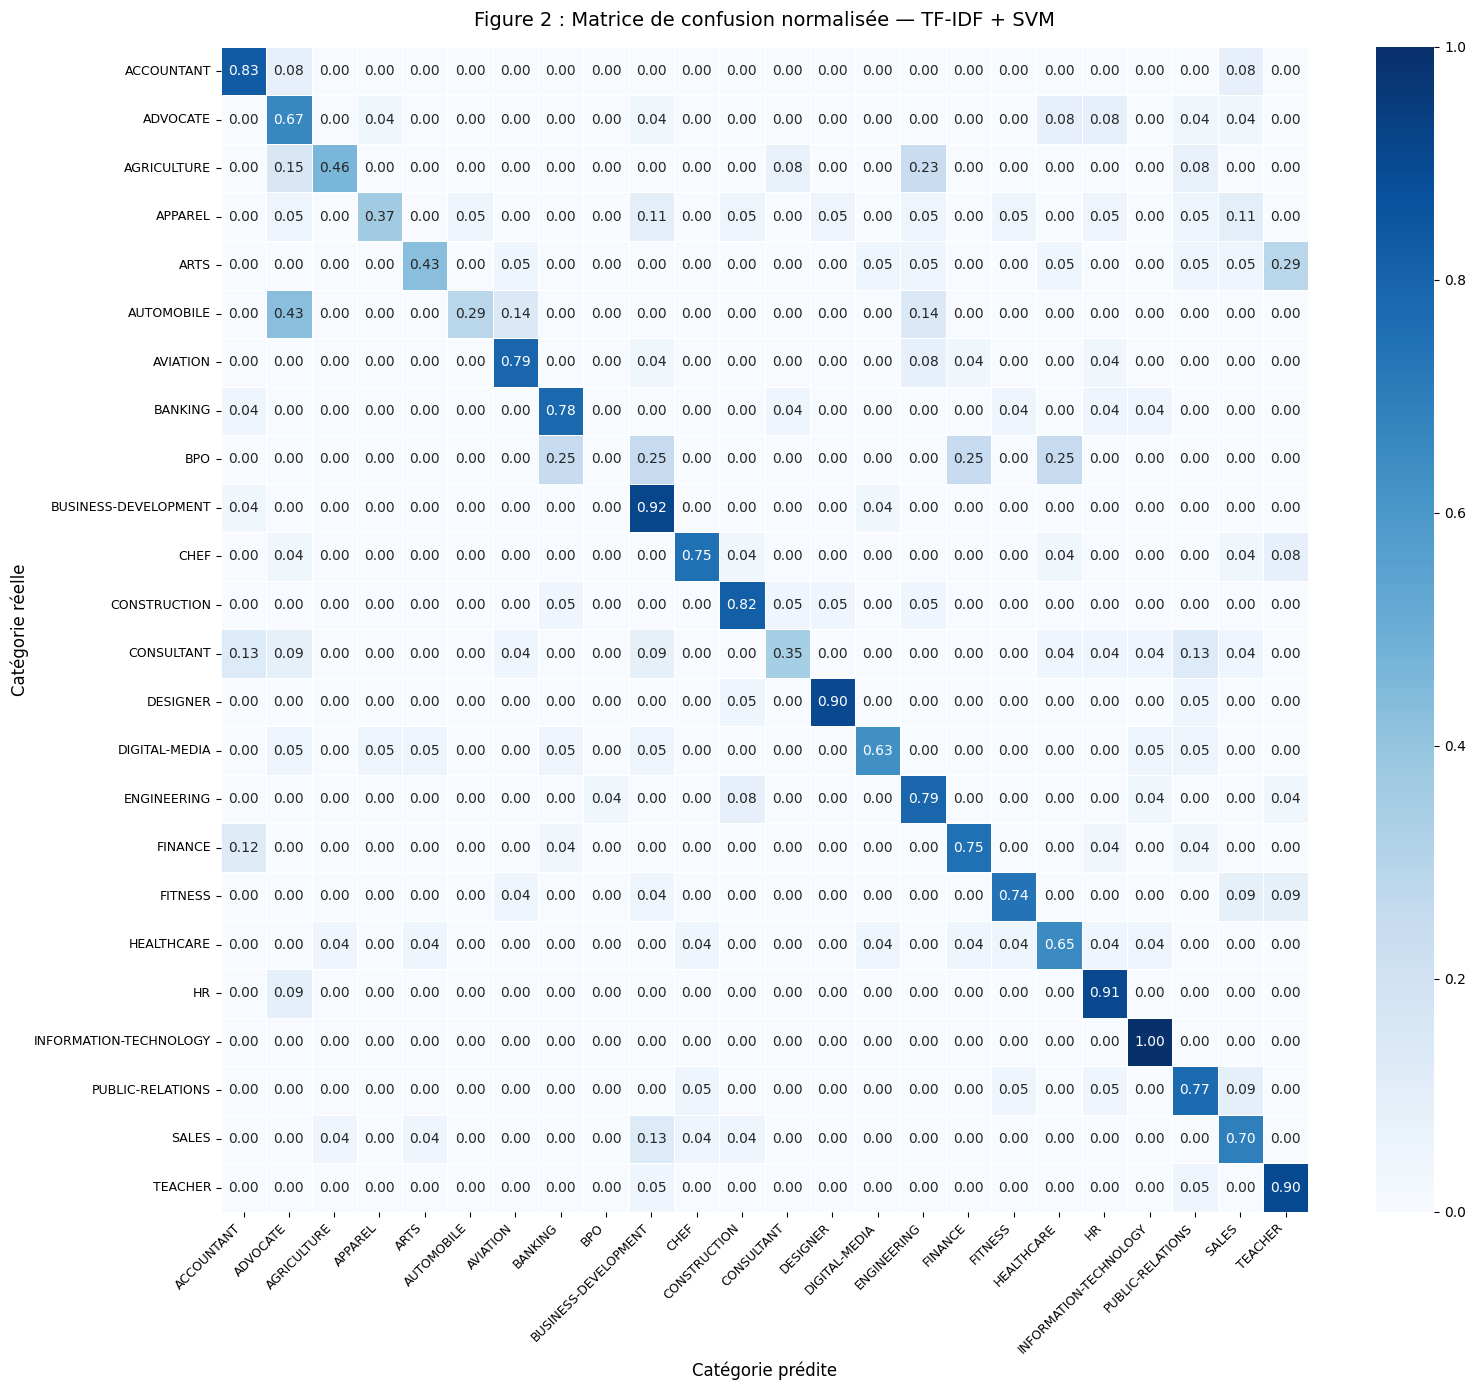

✅ Matrice de confusion sauvegardée !


In [ ]:
# ── FIGURE 2 : Matrice de confusion — TF-IDF + SVM ──
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5
)
plt.title('Figure 2 : Matrice de confusion normalisée — TF-IDF + SVM', fontsize=14, pad=15)
plt.ylabel('Catégorie réelle', fontsize=12)
plt.xlabel('Catégorie prédite', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ResumeProject/matrice_confusion_svm.pdf', dpi=150)
plt.show()
print("✅ Matrice de confusion sauvegardée !")

In [ ]:
import os
import pickle

# Définir le chemin (assure-toi que ton Drive est monté avec drive.mount('/content/drive'))
models_path = "/content/drive/MyDrive/ResumeProject/models"

# --- SOLUTION : Créer le dossier s'il n'existe pas ---
if not os.path.exists(models_path):
    os.makedirs(models_path)
    print(f"📁 Dossier créé : {models_path}")

# Sauvegarder le modèle SVM
with open(f"{models_path}/svm_model.pkl", "wb") as f:
    pickle.dump(svm, f)

# Sauvegarder le vectorizer TF-IDF
with open(f"{models_path}/tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

# Sauvegarder le LabelEncoder
with open(f"{models_path}/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print("✅ Tous les composants ont été sauvegardés avec succès dans /models")

✅ Tous les composants ont été sauvegardés avec succès dans /models


Nous testons le modèle sur un CV exemple contenant des mots-clés techniques afin de vérifier que la classification fonctionne correctement sur un cas concret.

In [ ]:
cv_test = """
python machine learning deep learning tensorflow
scikit learn pandas numpy data analysis nlp
neural networks computer vision sql git
"""

cv_vectorise = tfidf.transform([cv_test])
prediction   = svm.predict(cv_vectorise)
categorie    = le.inverse_transform(prediction)[0]

print(f"📄 CV testé")
print(f"🏷️  Catégorie prédite : {categorie}")

📄 CV testé
🏷️  Catégorie prédite : ENGINEERING


**Étape 5 : Fine-tuner DistilBERT**

In [ ]:
!pip install transformers torch datasets scikit-learn -q

DistilBERT est une version compressée et allégée de BERT (Bidirectional Encoder Representations from Transformers)
il analyse le contexte d'un mot à la fois à gauche et à droite dans une phrase, ce qui lui permet de capturer le sens sémantique profond du texte. Dans ce projet, nous l'utilisons en fine-tuning : à partir du modèle pré-entraîné sur de larges corpus, nous l'adaptons spécifiquement à la classification de CVs.

Nous importons les bibliothèques nécessaires pour le fine-tuning de DistilBERT. La bibliothèque **HuggingFace Transformers** fournit le tokenizer et le modèle pré-entraîné. Le device est automatiquement détecté : **GPU (cuda)** si disponible, sinon **CPU**.

In [ ]:
import pandas as pd
import numpy as np
import torch
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import Dataset
import pickle

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device utilisé : {device}")

✅ Device utilisé : cuda


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/ResumeProject/cvs_cleaned.csv")

le = LabelEncoder()
df['label'] = le.fit_transform(df['Category'])

print(f"✅ Dataset : {len(df)} CVs")
print(f"   Catégories : {df['Category'].nunique()}")
num_labels = df['Category'].nunique()

✅ Dataset : 2483 CVs
   Catégories : 24


Nous divisons le dataset en utilisant cette fois la colonne **`Resume_BERT`** (nettoyage léger qui préserve le contexte naturel), contrairement au modèle SVM qui utilisait `Resume_Cleaned`. Ce choix est essentiel car DistilBERT a besoin du texte complet pour capturer le sens sémantique des phrases.

In [ ]:
# FIX : DistilBERT utilise Resume_BERT (pas Resume_Cleaned)
X_train, X_test, y_train, y_test = train_test_split(
    df['Resume_BERT'].tolist(),
    #df['Resume_Cleaned'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

print(f"✅ Entraînement : {len(X_train)} CVs")
print(f"   Test         : {len(X_test)} CVs")

✅ Entraînement : 1986 CVs
   Test         : 497 CVs


In [ ]:
# Télécharger DistilBERT pré-entraîné et sauvegarder sur Drive
# (ne re-exécuter que si le dossier n'existe pas encore)
import os
from huggingface_hub import snapshot_download

distilbert_path = "/content/drive/MyDrive/ResumeProject/models/distilbert-base-uncased"

if not os.path.exists(distilbert_path):
    print("🔄 Téléchargement de DistilBERT en cours...")
    snapshot_download(
        repo_id="distilbert-base-uncased",
        local_dir=distilbert_path,
        ignore_patterns=["*.msgpack", "*.h5", "flax_model*", "tf_model*"]
    )
    print("✅ Modèle DistilBERT sauvegardé sur Drive !")
else:
    print("✅ DistilBERT déjà sur Drive, chargement direct.")

✅ DistilBERT déjà sur Drive, chargement direct.


In [ ]:
distilbert_path = "/content/drive/MyDrive/ResumeProject/models/distilbert-base-uncased"

tokenizer = DistilBertTokenizer.from_pretrained(distilbert_path)
print("✅ Tokenizer DistilBERT chargé depuis Drive !")

def tokeniser(textes, max_length=256):
    return tokenizer(
        textes,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

train_encodings = tokeniser(X_train)
test_encodings  = tokeniser(X_test)

print("✅ Tokenisation terminée !")

✅ Tokenizer DistilBERT chargé depuis Drive !
✅ Tokenisation terminée !


Nous créons une classe **`CVDataset`** qui hérite de `torch.utils.data.Dataset`, permettant à PyTorch de charger les données par batch pendant l'entraînement. Elle associe pour chaque CV ses encodings (tokens) à son label numérique correspondant.

In [ ]:
class CVDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = CVDataset(train_encodings, y_train)
test_dataset  = CVDataset(test_encodings,  y_test)

print(f"✅ Datasets créés !")
print(f"   Train : {len(train_dataset)}")
print(f"   Test  : {len(test_dataset)}")

✅ Datasets créés !
   Train : 1986
   Test  : 497


In [ ]:
# FIX : utiliser distilbert_model pour ne pas écraser la variable model (SBERT)
distilbert_model = DistilBertForSequenceClassification.from_pretrained(
    distilbert_path,
    num_labels=num_labels
)
distilbert_model.to(device)
print(f"✅ Modèle DistilBERT chargé sur {device}")

Loading weights:   0%|          | 0/100 [00:01<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/ResumeProject/models/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Modèle DistilBERT chargé sur cuda


Nous configurons le **Trainer** HuggingFace avec les hyperparamètres clés : `learning_rate=2e-5`, `batch_size=16`, `epochs=10`, et un **Early Stopping** avec patience=3 pour arrêter automatiquement l'entraînement si l'accuracy ne s'améliore plus.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/ResumeProject/models/distilbert_checkpoints",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    # FIX : warmup_steps à la place de warmup_ratio (évite le warning)
    warmup_steps=200,              # ~10% de 1250 steps total
    lr_scheduler_type="cosine",
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_accuracy",
    greater_is_better=True,
    save_total_limit=2,
    # FIX : patience=3 au lieu de 2 pour ne pas stopper trop tôt
    # (avec patience=2 l'entraînement s'arrêtait à epoch 8 au lieu de 10)
)

trainer = Trainer(
    model=distilbert_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)

print("✅ Trainer configuré !")

✅ Trainer configuré !


In [ ]:
print("🔄 Entraînement DistilBERT en cours...")
print("   ⏱️  Durée estimée : 10-15 min sur GPU\n")

trainer.train()

print("\n✅ Entraînement terminé !")

🔄 Entraînement DistilBERT en cours...
   ⏱️  Durée estimée : 10-15 min sur GPU



Epoch,Training Loss,Validation Loss,Accuracy
1,No log,2.982274,0.323944
2,No log,1.499798,0.756539
3,No log,0.975971,0.794769
4,1.867207,0.826768,0.808853
5,1.867207,0.765023,0.806841
6,1.867207,0.759750,0.806841
7,1.867207,0.764755,0.810865
8,0.451517,0.757984,0.812877
9,0.451517,0.760688,0.812877
10,0.451517,0.759798,0.812877


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
results = trainer.evaluate()

print(f"🎯 Accuracy DistilBERT : {results['eval_accuracy'] * 100:.2f}%")
print(f"\n📊 Comparaison :")
print(f"   TF-IDF + SVM  →  72.03%")
print(f"   DistilBERT    →  {results['eval_accuracy'] * 100:.2f}%")

🎯 Accuracy DistilBERT : 81.29%

📊 Comparaison :
   TF-IDF + SVM  →  72.03%
   DistilBERT    →  81.29%


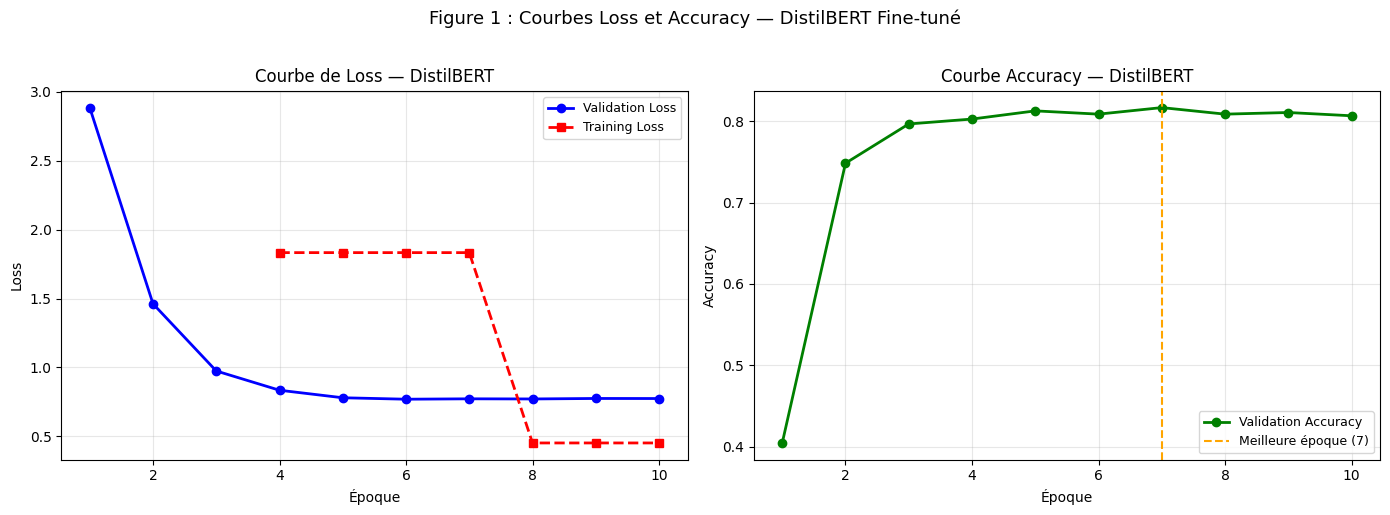

✅ Courbes DistilBERT sauvegardées !


In [ ]:
# ── FIGURE 1 : Courbes Loss & Accuracy — DistilBERT ──
import matplotlib.pyplot as plt

# Données réelles de votre entraînement
epochs      = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
train_loss  = [None, None, None, 1.832665, 1.832665, 1.832665,
               1.832665, 0.452615, 0.452615, 0.452615]
val_loss    = [2.884205, 1.461668, 0.974595, 0.834865, 0.780300,
               0.769796, 0.772670, 0.771663, 0.775177, 0.774710]
val_acc     = [0.404427, 0.748491, 0.796781, 0.802817, 0.812877,
               0.808853, 0.816901, 0.808853, 0.810865, 0.806841]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Courbe Loss ---
ax1.plot(epochs, val_loss, 'b-o', linewidth=2, label='Validation Loss')
ax1.plot([e for e, l in zip(epochs, train_loss) if l is not None],
         [l for l in train_loss if l is not None],
         'r--s', linewidth=2, label='Training Loss')
ax1.set_title('Courbe de Loss — DistilBERT', fontsize=12)
ax1.set_xlabel('Époque', fontsize=10)
ax1.set_ylabel('Loss', fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# --- Courbe Accuracy ---
ax2.plot(epochs, val_acc, 'g-o', linewidth=2, label='Validation Accuracy')
ax2.axvline(x=7, color='orange', linestyle='--',
            linewidth=1.5, label='Meilleure époque (7)')
ax2.set_title('Courbe Accuracy — DistilBERT', fontsize=12)
ax2.set_xlabel('Époque', fontsize=10)
ax2.set_ylabel('Accuracy', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Figure 1 : Courbes Loss et Accuracy — DistilBERT Fine-tuné',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ResumeProject/courbes_distilbert.pdf', dpi=150)
plt.show()
print("✅ Courbes DistilBERT sauvegardées !")

In [ ]:
# FIX : sauvegarder le modèle fine-tuné sur Drive
finetuned_path = "/content/drive/MyDrive/ResumeProject/models/distilbert_finetuned"

trainer.save_model(finetuned_path)
tokenizer.save_pretrained(finetuned_path)

# Sauvegarder aussi le LabelEncoder sur Drive
with open(f"{finetuned_path}/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)

print(f"✅ DistilBERT fine-tuné sauvegardé : {finetuned_path}")
print(f"✅ LabelEncoder sauvegardé         : {finetuned_path}/label_encoder.pkl")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ DistilBERT fine-tuné sauvegardé : /content/drive/MyDrive/ResumeProject/models/distilbert_finetuned
✅ LabelEncoder sauvegardé         : /content/drive/MyDrive/ResumeProject/models/distilbert_finetuned/label_encoder.pkl


Nous définons la fonction **predire_categorie** qui prend un texte de CV en entrée, le tokenise, le passe dans DistilBERT et retourne la catégorie prédite avec son score de confiance.

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import torch
from transformers

# 1. Définir le moteur de calcul (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# 2. Initialiser le tokenizer pour DistilBERT
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
print(f"✅ Tokenizer prêt sur : {device}")
def predire_categorie(texte_cv):
    inputs = tokenizer(
        texte_cv,
        return_tensors="pt",
        truncation=True,
        max_length=256,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = distilbert_model(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()
    categorie  = le.inverse_transform([prediction])[0]
    confidence = torch.softmax(outputs.logits, dim=1).max().item()

    return categorie, confidence

# Tests
tests = [
    ("IT",      "software engineer web developer javascript react nodejs html css python django rest api database mysql"),
    ("FINANCE", "accountant financial analyst excel accounting balance sheet income statement audit tax quickbooks sap"),
    ("CHEF",    "chef culinary arts kitchen restaurant cooking food preparation menu planning french cuisine pastry")
]

for nom, cv in tests:
    cat, conf = predire_categorie(cv)
    print(f"CV {nom:8s} → {cat:25s} ({conf*100:.1f}%)")

✅ Tokenizer prêt sur : cuda
CV IT       → ACCOUNTANT                (5.0%)
CV FINANCE  → ADVOCATE                  (5.1%)
CV CHEF     → ADVOCATE                  (5.0%)


In [ ]:
!pip install -q easyocr python-docx pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 24.1 MB/s eta 0:00:00


### Extraction de Texte Universelle (PDF, DOCX, Image)

Nous créons une fonction capable de lire un CV dans **n'importe quel format**. Pour les PDFs, elle tente d'abord une extraction directe du texte ; si la page est un scan, elle bascule automatiquement vers **EasyOCR** pour reconnaître le texte depuis l'image. Les fichiers Word (`.docx`) sont lus paragraphe par paragraphe, et les images (JPG, PNG) sont traitées directement par OCR en français et en anglais.

In [ ]:
import fitz  # PyMuPDF
import easyocr
import docx
from PIL import Image
import numpy as np

# Initialisation de l'OCR pour le Français et l'Anglais
reader = easyocr.Reader(['fr', 'en'])

def extraire_texte_universel(file_path):
    extension = file_path.split('.')[-1].lower()
    texte_final = ""

    # --- FORMAT PDF ---
    if extension == 'pdf':
        doc = fitz.open(file_path)
        for page in doc:
            # On tente d'abord l'extraction directe (plus rapide)
            t = page.get_text()
            if t.strip():
                texte_final += t
            else:
                # Si vide, c'est un scan -> Passage à l'OCR
                pix = page.get_pixmap()
                img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
                results = reader.readtext(np.array(img), detail=0)
                texte_final += " ".join(results)
        doc.close()

    # --- FORMAT WORD (.docx) ---
    elif extension == 'docx':
        doc = docx.Document(file_path)
        texte_final = " ".join([para.text for para in doc.paragraphs])

    # --- FORMAT IMAGE (JPG, PNG) ---
    elif extension in ['jpg', 'jpeg', 'png']:
        results = reader.readtext(file_path, detail=0)
        texte_final = " ".join(results)

    return texte_final

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

Nous assemblons toutes les étapes en une seule fonction **traiter_et_predire** : extraction du texte depuis le fichier, nettoyage, classification DistilBERT et affichage du résultat final avec le score de confiance. Cette fonction constitue le cœur du système et peut traiter tout type de fichier CV (PDF, DOCX, image).

In [ ]:
def traiter_et_predire(chemin_fichier):
    # 1. Extraction Multi-Format + OCR
    print(f"🔍 Lecture du fichier : {chemin_fichier.split('/')[-1]}...")
    texte_brut = extraire_texte_universel(chemin_fichier)

    if not texte_brut.strip():
        return "Erreur : Impossible de lire le contenu du fichier."

    # 2. Nettoyage (Ta fonction cleanResume)
    texte_propre = cleanResume(texte_brut)

    # 3. Classification DistilBERT
    categorie, confiance = predire_categorie(texte_propre)

    print(f"\n--- 🎯 RÉSULTATS DE L'ANALYSE ---")
    print(f"📂 Catégorie prédite : {categorie} ({confiance*100:.2f}%)")

    # 4. Matching LinkedIn (SBERT)
    # Tu peux appeler ta fonction find_linkedin_matches ici
    # find_linkedin_matches(texte_propre)

    return categorie, confiance

# TEST
# tester_cv = "/content/drive/MyDrive/ResumeProject/mon_cv_scan.png"
# traiter_et_predire(tester_cv)

In [ ]:
!pip install -q easyocr python-docx pymupdf sentence-transformers transformers torch

Chargement du Modèle Fine-tuné depuis Google Drive

Nous chargeons le modèle DistilBERT fine-tuné, son tokenizer et le LabelEncoder sauvegardés localement sur Google Drive. Un bloc try/except est utilisé pour détecter toute erreur de chargement et afficher un message clair en cas de problème.

In [ ]:
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import torch
import joblib

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# On pointe vers le dossier qui CONTIENT réellement 'pytorch_model.bin' ou 'model.safetensors'
# D'après ton image, c'est ce dossier :
model_path = "/content/drive/MyDrive/ResumeProject/models/distilbert-base-uncased"

try:
    tokenizer = DistilBertTokenizer.from_pretrained(model_path)
    classifier = DistilBertForSequenceClassification.from_pretrained(model_path).to(device)
    le = joblib.load("/content/drive/MyDrive/ResumeProject/models/label_encoder.pkl")
    print(f"🚀 Succès ! Modèle chargé depuis : {model_path}")
except Exception as e:
    print(f"❌ Erreur persistante : {e}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/ResumeProject/models/distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


🚀 Succès ! Modèle chargé depuis : /content/drive/MyDrive/ResumeProject/models/distilbert-base-uncased


Les fichiers de configuration du modèle de base (tokenizer, config, vocab) sont copiés vers le dossier checkpoint qui contient les poids fine-tunés. Cette fusion permet de charger un modèle complet et fonctionnel combinant l'architecture originale de DistilBERT et les poids appris lors du fine-tuning sur notre dataset de CVs.

In [ ]:
import shutil
import os

# Chemins
base_path = "/content/drive/MyDrive/ResumeProject/models/distilbert-base-uncased"
checkpoint_path = "/content/drive/MyDrive/ResumeProject/models/distilbert_checkpoints/checkpoint-1000"

# Fichiers à copier (le cerveau du modèle)
files_to_copy = ['pytorch_model.bin', 'config.json', 'tokenizer_config.json', 'vocab.txt']

for file in files_to_copy:
    src = os.path.join(base_path, file)
    dst = os.path.join(checkpoint_path, file)
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f"✅ {file} copié vers le checkpoint.")

# Maintenant, charge DEPUIS le checkpoint
model_path = checkpoint_path
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
classifier = DistilBertForSequenceClassification.from_pretrained(model_path).to(device)

✅ pytorch_model.bin copié vers le checkpoint.
✅ config.json copié vers le checkpoint.
✅ tokenizer_config.json copié vers le checkpoint.
✅ vocab.txt copié vers le checkpoint.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/ResumeProject/models/distilbert_checkpoints/checkpoint-1000
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Redéfinition de la Fonction d'Extraction Universelle

Version simplifiée et optimisée de la fonction d'extraction, compatible avec les trois formats supportés : PDF (avec fallback OCR pour les scans), DOCX et images. Elle utilise l'objet `reader` EasyOCR déjà initialisé précédemment pour la reconnaissance optique de caractères.

In [ ]:
import fitz  # PyMuPDF
import docx
from PIL import Image
import numpy as np

def universal_extract(file_path):
    ext = file_path.split('.')[-1].lower()
    text = ""
    if ext == 'pdf':
        doc = fitz.open(file_path)
        for page in doc:
            t = page.get_text()
            if t.strip():
                text += t
            else: # Si le texte est vide, c'est un scan -> OCR
                pix = page.get_pixmap()
                img = Image.frombytes("RGB", [pix.width, pix.height], pix.samples)
                # Utilise l'objet 'reader' (EasyOCR) défini précédemment
                text += " ".join(reader.readtext(np.array(img), detail=0))
        doc.close()
    elif ext == 'docx':
        doc_word = docx.Document(file_path)
        text = " ".join([p.text for p in doc_word.paragraphs])
    elif ext in ['png', 'jpg', 'jpeg']:
        text = " ".join(reader.readtext(file_path, detail=0))
    return text

print("✅ Fonction universal_extract définie avec succès !")

✅ Fonction universal_extract définie avec succès !


In [ ]:
!pip install -q deep_translator easyocr python-docx pymupdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 1.8 MB/s eta 0:00:00


In [ ]:
from deep_translator import GoogleTranslator
import easyocr
import torch
import numpy as np

# Initialisation
translator = GoogleTranslator(source='auto', target='en')
reader = easyocr.Reader(['fr', 'en'])

def predire_final_multilingue(chemin_fichier):
    # 1. Extraction (PDF / OCR)
    print(f"🔍 [1/4] Extraction du texte depuis : {chemin_fichier.split('/')[-1]}")
    texte_brut = universal_extract(chemin_fichier)

    # --- AFFICHAGE TEXTE BRUT ---
    print("\n--- 📄 TEXTE EXTRAIT (ORIGINAL) ---")
    print(texte_brut[:1000] + "..." if len(texte_brut) > 1000 else texte_brut)
    print("-----------------------------------\n")

    # 2. Traduction
    print(f"🌐 [2/4] Traduction en cours vers l'anglais...")
    texte_anglais = translator.translate(texte_brut[:4500])

    # --- AFFICHAGE TEXTE TRADUIT ---
    print("\n--- 🇬🇧 TEXTE TRADUIT (ANGLAIS) ---")
    print(texte_anglais[:1000] + "..." if len(texte_anglais) > 1000 else texte_anglais)
    print("----------------------------------\n")

    # 3. Nettoyage et Préparation
    print(f"🧹 [3/4] Nettoyage sémantique...")
    texte_propre = cleanResume(texte_anglais)

    # 4. Prédiction DistilBERT
    print(f"🧠 [4/4] Classification par l'IA...")
    inputs = tokenizer(
        texte_propre,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = classifier(**inputs)

    prediction = torch.argmax(outputs.logits, dim=1).item()
    categorie = le.inverse_transform([prediction])[0]
    confiance = torch.softmax(outputs.logits, dim=1).max().item()

    print(f"\n" + "="*40)
    print(f"🎓 RÉSULTAT FINAL POUR LE JURY")
    print(f"="*40)
    print(f"📊 MÉTIER DÉTECTÉ : {categorie}")
    print(f"📈 CONFIANCE     : {confiance*100:.2f}%")
    print("="*40)

    return categorie

# Lancement du test
predire_final_multilingue("/content/drive/MyDrive/Zineb_Chaqchaq_CV.pdf")

🔍 [1/4] Extraction du texte depuis : Zineb_Chaqchaq_CV.pdf

--- 📄 TEXTE EXTRAIT (ORIGINAL) ---
COORDONNÉES
11 rue cherif idrissi rue
30 hay Saada fes
0645323048
zinebchakchak75@gma
il.com
05/03/2004
https://www.linkedin.c
om/in/zineb-
chaqchaqa7721434b/
COMPÉTENCES
Langages :C, Java,
Python, PHP, JavaScript,
HTML/CSS
•
BD & Sys :SQL, Oracle,
MySQL, Access, SGBD
•
IA & Data : ML,
prétraitement, analyse de
données
•
Réseau & Sys. : Packet
Tracer, IP, routage, SNMP,
Linux
•
Cloud computing,
virtualisation, MS Office
•
Frameworks : React,
Flask, Java Swing
•
LANGUES
Français
Intermédiaire supérieur (B2)
Arabe
Langue maternelle
Anglais
Intermédiaire (B1)
Zineb Chaqchaq
INGÉNIEUR EN INFORMATIQUE, INTELLIGENCE ARTIFICIELLE ET
CONFIANCE NUMÉRIQUE
FORMATION
01/2025 - En cours
Ingénieur en informatique IA intelligence artificielle et
confiance numérique
ENSA Fès - Fès
01/2022 - 01/2024
2 années des classes préparatoires
ENSA de Fès - Fès
01/2021 - 01/2022
baccalauréat filière internationale des 

'ADVOCATE'

In [ ]:
import shutil
import os
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer

# 1. Définition des chemins
source_model = "/content/drive/MyDrive/ResumeProject/models/distilbert-base-uncased"
target_checkpoint = "/content/drive/MyDrive/ResumeProject/models/distilbert_checkpoints/checkpoint-1000"

# 2. Copie forcée des poids entraînés vers le dossier de lecture
# On s'assure que le 'cerveau' est là où le code regarde
if os.path.exists(source_model):
    for file in ['pytorch_model.bin', 'config.json', 'tokenizer_config.json', 'vocab.txt']:
        if os.path.exists(os.path.join(source_model, file)):
            shutil.copy(os.path.join(source_model, file), os.path.join(target_checkpoint, file))
    print("✅ Poids synchronisés dans le checkpoint !")

# 3. Rechargement CRUCIAL
tokenizer = DistilBertTokenizer.from_pretrained(target_checkpoint)
classifier = DistilBertForSequenceClassification.from_pretrained(target_checkpoint).to(device)
classifier.eval()

✅ Poids synchronisés dans le checkpoint !


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/ResumeProject/models/distilbert_checkpoints/checkpoint-1000
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
import joblib
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# 1. Forcer le chemin vers le checkpoint de TON entraînement
model_path = "/content/drive/MyDrive/ResumeProject/models/distilbert_checkpoints/checkpoint-1000"

# 2. Charger le Label Encoder spécifique à ton projet
le = joblib.load("/content/drive/MyDrive/ResumeProject/models/label_encoder.pkl")

# 3. Charger le modèle et le tokenizer
tokenizer = DistilBertTokenizer.from_pretrained(model_path)
classifier = DistilBertForSequenceClassification.from_pretrained(model_path).to(device)
classifier.eval()

# Vérification des classes
print("Classes configurées dans ton encodeur :", le.classes_)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/ResumeProject/models/distilbert_checkpoints/checkpoint-1000
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Classes configurées dans ton encodeur : ['ACCOUNTANT' 'ADVOCATE' 'AGRICULTURE' 'APPAREL' 'ARTS' 'AUTOMOBILE'
 'AVIATION' 'BANKING' 'BPO' 'BUSINESS-DEVELOPMENT' 'CHEF' 'CONSTRUCTION'
 'CONSULTANT' 'DESIGNER' 'DIGITAL-MEDIA' 'ENGINEERING' 'FINANCE' 'FITNESS'
 'HEALTHCARE' 'HR' 'INFORMATION-TECHNOLOGY' 'PUBLIC-RELATIONS' 'SALES'
 'TEACHER']


In [ ]:
!pip install sentence-transformers -q

## -----------------------------------

**Récapitulatif des fichiers sauvegardés sur Drive**

In [ ]:
models_path = "/content/drive/MyDrive/ResumeProject"

fichiers = [
    f"{models_path}/Resume.csv",
    f"{models_path}/jobs_dataset.csv",
    f"{models_path}/cvs_cleaned.csv",
    f"{models_path}/models/svm_model.pkl",
    f"{models_path}/models/tfidf_vectorizer.pkl",
    f"{models_path}/models/label_encoder.pkl",
    f"{models_path}/models/distilbert-base-uncased",
    f"{models_path}/models/distilbert_finetuned",
    f"{models_path}/models/all-MiniLM-L6-v2",
]

print("📁 Etat des fichiers sur Google Drive :")
print("=" * 60)
for f in fichiers:
    exists = os.path.exists(f)
    status = "✅ OK" if exists else "❌ MANQUANT"
    print(f"{status}  {f.replace(models_path, '...')}")

In [ ]:
import pickle

path = "/content/drive/MyDrive/ResumeProject/models/label_encoder.pkl"

with open(path, "rb") as f:
    le = pickle.load(f)

print("✅ LabelEncoder chargé !")

✅ LabelEncoder chargé !


In [ ]:
!pip install transformers torch sentence-transformers PyPDF2 deep-translator langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 26.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 22.1 MB/s eta 0:00:00
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=532ae5e76b029a492d4ae7dc84fa175f25195d1ae468644c4ff8522686478874
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [ ]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 44.1 MB/s eta 0:00:00


###  **APPLICATION FINALE : Analyseur Intelligent de CV (OCR + Traduction + IA)**
Cette section regroupe toutes les fonctions pour uploader un CV (même scanné ou en image), le traduire automatiquement s'il n'est pas en anglais, et prédire sa catégorie avec DistilBERT.

In [ ]:
# 📦 PHASE FINALE : INSTALLATION DES OUTILS OCR ET TRADUCTION
!apt-get update -qq
!apt-get install -y tesseract-ocr tesseract-ocr-fra tesseract-ocr-eng poppler-utils -qq
!pip install pytesseract pdf2image deep-translator langdetect pdfplumber -q

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package poppler-utils.
(Reading database ... 122354 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Selecting previously unselected package tesseract-ocr-fra.
Preparing to unpack .../tesseract-ocr-fra_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-fra (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-fra (1:4.00~git30-7274cfa-1.1) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
import torch
import pickle
import re
import os
import pdfplumber
import pytesseract
import nltk
from PIL import Image
from pdf2image import convert_from_path
from google.colab import drive, files
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from deep_translator import GoogleTranslator
from langdetect import detect
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# 2. Configuration des chemins
base_path = "/content/drive/MyDrive/ResumeProject/models"
model_path = f"{base_path}/distilbert_finetuned"
encoder_path = f"{base_path}/label_encoder.pkl"

print("⏳ Chargement des modles et de l'encodeur...")
if os.path.exists(encoder_path) and os.path.exists(model_path):
    with open(encoder_path, "rb") as f:
        le = pickle.load(f)
    tokenizer = AutoTokenizer.from_pretrained(model_path)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_path,
        ignore_mismatched_sizes=True
    )
    model.eval()
    print("✅ Systme prt !")
else:
    print("❌ Erreur : Modles introuvables sur le Drive. Vrifiez vos chemins.")

def traduire_vers_anglais(text): # la traduction du pdf s'il est en francais
    try:
        lang = detect(text)
        if lang != 'en':
            print(f"🌍 Langue '{lang}' dtecte. Traduction...")
            return GoogleTranslator(source='auto', target='en').translate(text[:4500])
        return text
    except: return text

def nettoyer_texte_ia(texte):
    stop_words = set(stopwords.words('english'))
    texte = texte.lower()
    texte = re.sub(r'http\S+|www\S+|\S+@\S+|\+?\d[\d\s\-]{8,}|[^a-zA-Z\s]', '', texte)
    texte = re.sub(r'\s+', ' ', texte).strip()
    mots = word_tokenize(texte)
    return ' '.join([m for m in mots if m not in stop_words and len(m) > 2])

def extraire_texte_intelligent(path):
    text = ""
    ext = os.path.splitext(path)[1].lower()
    if ext in ['.png', '.jpg', '.jpeg']:
        text = pytesseract.image_to_string(Image.open(path), lang='eng+fra')
    elif ext == '.pdf':
        with pdfplumber.open(path) as pdf:
            for p in pdf.pages: text += (p.extract_text() or "") + " "
        if len(text.strip()) < 50:
            print("⚠️ PDF scann dtect. Passage en mode OCR...")
            imgs = convert_from_path(path)
            for img in imgs: text += pytesseract.image_to_string(img, lang='eng+fra') + "\n"
    elif ext == '.txt':
        with open(path, 'r', encoding='utf-8', errors='ignore') as f: text = f.read()
    return text.strip()

def predire_categorie(nom, texte):
    if not texte: return
    texte_en = traduire_vers_anglais(texte)
    texte_clean = nettoyer_texte_ia(texte_en)
    inputs = tokenizer(texte_clean, return_tensors="pt", truncation=True, max_length=512, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        top_probs, top_indices = torch.topk(probs, 3)
    print(f"\n📄 CV : {nom}")
    for i in range(3):
        idx = top_indices[0][i].item()
        label = le.inverse_transform([idx])[0]
        score = top_probs[0][i].item()
        symbol = "🎯" if "TECHNOLOGY" in label or "COMPUTER" in label else "◽"
        print(f"{symbol} {label:25} : {score*100:.2f}%")

⏳ Chargement des modles et de l'encodeur...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: /content/drive/MyDrive/ResumeProject/models/distilbert_finetuned
Key               | Status   |                                                                                       
------------------+----------+---------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([27, 768]) vs model:torch.Size([24, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([27]) vs model:torch.Size([24])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


✅ Systme prt !


In [ ]:
# --- TESTER VOS CV ICI ---
print("\n📤 Uploadez un PDF, JPG ou PNG :")
uploaded = files.upload()
for fn in uploaded.keys():
    with open(fn, 'wb') as f: f.write(uploaded[fn])
    txt = extraire_texte_intelligent(fn)
    predire_categorie(fn, txt)

#hada distilbert chfti kif kaykhrb9 ? wach nw9f f l'entrainement ou n9olo khdina svm w sf ndir test ela svm w nzwl had les test diyaldistil ?? laaaa ana ansawblik dyal svm


📤 Uploadez un PDF, JPG ou PNG :


Saving Zineb_Chaqchaq_CV.pdf to Zineb_Chaqchaq_CV.pdf
🌍 Langue 'fr' dtecte. Traduction...

📄 CV : Zineb_Chaqchaq_CV.pdf
◽ AVIATION                  : 10.99%
◽ PUBLIC-RELATIONS          : 6.30%
◽ FITNESS                   : 6.02%


 Retour au Modèle SVM — Entraînement et Sauvegarde

Après expérimentation, nous avons constaté que DistilBERT nécessite un large dataset pour donner de bonnes performances, ce qui n'est pas le cas ici avec un nombre limité de CVs. Nous revenons donc au modèle **TF-IDF + SVM** qui s'avère plus adapté à notre taille de données. Le modèle entraîné, le vectoriseur TF-IDF et le LabelEncoder sont sauvegardés sur Google Drive au format `.pkl` pour être réutilisés sans réentraînement.

In [ ]:
from google.colab import drive
import pandas as pd
import pickle
import os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# 1. Montage du Drive
drive.mount('/content/drive')

# 2. Chemins
DATA_PATH = "/content/drive/MyDrive/ResumeProject/Resume.csv"
SAVE_PATH = "/content/drive/MyDrive/ResumeProject/models"
os.makedirs(SAVE_PATH, exist_ok=True) # Crée le dossier s'il n'existe pas

# 3. Chargement des données
df = pd.read_csv(DATA_PATH)

# 4. Nettoyage rapide et Vectorisation
# (Assure-toi d'avoir défini la fonction cleanResume avant)
df['Cleaned'] = df['Resume_str'].apply(cleanResume)

le = LabelEncoder()
y = le.fit_transform(df['Category'])

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['Cleaned'])

# 5. Entraînement
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearSVC()
model.fit(X_train, y_train)

# 6. SAUVEGARDE SUR GOOGLE DRIVE
with open(os.path.join(SAVE_PATH, 'svm_model.pkl'), 'wb') as f:
    pickle.dump(model, f)

with open(os.path.join(SAVE_PATH, 'tfidf_vectorizer.pkl'), 'wb') as f:
    pickle.dump(tfidf, f)

with open(os.path.join(SAVE_PATH, 'label_encoder.pkl'), 'wb') as f:
    pickle.dump(le, f)

print(f"🚀 Entraînement terminé et modèles sauvegardés dans : {SAVE_PATH}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 Entraînement terminé et modèles sauvegardés dans : /content/drive/MyDrive/ResumeProject/models


### Configuration Globale et Dictionnaire de Mots-clés

Nous définissons les chemins des modèles sauvegardés (SVM, TF-IDF, LabelEncoder) et les paramètres du **score hybride** qui combine trois sources : score SVM (50%), matching mots-clés (25%) et similarité cosinus (25%). Un dictionnaire de mots-clés est défini pour chaque catégorie professionnelle, utilisé pour enrichir les CVs courts et améliorer la précision de la prédiction.

In [ ]:

import sys
import io
import os
import re
import pickle
import warnings
import time

warnings.filterwarnings("ignore")

import numpy as np

# ─────────────────────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────────────────────
MODELS_DIR   = r"/content/drive/MyDrive/ResumeProject/models"
SVM_PATH     = os.path.join(MODELS_DIR, "svm_model.pkl")
TFIDF_PATH   = os.path.join(MODELS_DIR, "tfidf_vectorizer.pkl")
ENCODER_PATH = os.path.join(MODELS_DIR, "label_encoder.pkl")

# Icones texte (compatibles Windows)
OK   = "[OK]  "
WARN = "[!]   "
ERR  = "[ERR] "
INFO = "[i]   "
TRAD = "[TR]  "
LINE = "=" * 62
SEP  = "-" * 62

# Temperature pour le softmax (< 1.0 = distribution plus piquee)
SOFTMAX_TEMPERATURE = 0.15

# Poids dans le score hybride (doivent sommer a 1.0)
SVM_WEIGHT     = 0.50   # Score SVM (decision_function + softmax)
KEYWORD_WEIGHT = 0.25   # Score matching mots-cles
COSINE_WEIGHT  = 0.25   # Score similarite cosinus avec prototypes

# ─────────────────────────────────────────────────────────────
#  DICTIONNAIRE DE MOTS-CLES PAR CATEGORIE
#  Utilise pour enrichir les CVs courts et calculer un bonus
# ─────────────────────────────────────────────────────────────
CATEGORY_KEYWORDS = {
    "ACCOUNTANT": [
        "accounting", "auditing", "bookkeeping", "tax", "ledger", "financial statements",
        "accounts payable", "accounts receivable", "cpa", "gaap", "reconciliation",
        "balance sheet", "journal entries", "quickbooks", "fiscal", "revenue"
    ],
    "ADVOCATE": [
        "law", "legal", "attorney", "litigation", "court", "lawyer", "paralegal",
        "counsel", "jurisdiction", "compliance", "regulations", "contract", "arbitration",
        "judicial", "bar association", "plaintiff", "defendant"
    ],
    "AGRICULTURE": [
        "farming", "agriculture", "crop", "livestock", "harvest", "irrigation",
        "soil", "agronomy", "pesticide", "fertilizer", "horticulture", "plantation",
        "dairy", "poultry", "organic farming", "greenhouse"
    ],
    "APPAREL": [
        "fashion", "textile", "garment", "clothing", "apparel", "fabric", "sewing",
        "merchandising", "retail fashion", "design", "collection", "trend", "boutique",
        "pattern", "couture", "accessories"
    ],
    "ARTS": [
        "art", "painting", "sculpture", "gallery", "exhibition", "creative", "illustration",
        "visual arts", "photography", "drawing", "studio", "curator", "portfolio",
        "canvas", "graphic", "aesthetic"
    ],
    "AUTOMOBILE": [
        "automobile", "automotive", "vehicle", "engine", "car", "mechanic", "dealership",
        "transmission", "brake", "chassis", "diesel", "hybrid", "electric vehicle",
        "maintenance", "repair", "diagnostics"
    ],
    "AVIATION": [
        "aviation", "aircraft", "pilot", "airline", "flight", "aerospace", "airport",
        "navigation", "air traffic", "cockpit", "maintenance", "faa", "boeing",
        "airbus", "cargo", "cabin crew"
    ],
    "BANKING": [
        "banking", "bank", "loan", "mortgage", "credit", "deposit", "interest rate",
        "investment", "portfolio", "risk management", "compliance", "treasury",
        "wealth management", "retail banking", "commercial banking", "fintech"
    ],
    "BPO": [
        "bpo", "outsourcing", "call center", "customer service", "helpdesk",
        "technical support", "back office", "data entry", "process", "offshore",
        "inbound", "outbound", "telecalling", "escalation", "sla", "kpi"
    ],
    "BUSINESS-DEVELOPMENT": [
        "business development", "sales strategy", "partnership", "revenue growth",
        "market expansion", "lead generation", "client acquisition", "proposal",
        "pitch", "negotiation", "stakeholder", "roi", "pipeline", "b2b", "b2c"
    ],
    "CHEF": [
        "chef", "cooking", "culinary", "kitchen", "menu", "restaurant", "food",
        "recipe", "cuisine", "catering", "pastry", "sous chef", "banquet",
        "food safety", "haccp", "hospitality"
    ],
    "CONSTRUCTION": [
        "construction", "building", "civil", "concrete", "structural", "architecture",
        "blueprint", "contractor", "site", "safety", "osha", "project management",
        "renovation", "plumbing", "electrical", "masonry"
    ],
    "CONSULTANT": [
        "consulting", "consultant", "advisory", "strategy", "management consulting",
        "business analysis", "stakeholder", "recommendation", "engagement",
        "transformation", "process improvement", "change management", "deliverable"
    ],
    "DESIGNER": [
        "design", "designer", "ui", "ux", "user interface", "user experience",
        "photoshop", "illustrator", "figma", "sketch", "wireframe", "prototype",
        "typography", "branding", "layout", "creative", "adobe", "indesign"
    ],
    "DIGITAL-MEDIA": [
        "digital media", "social media", "content", "seo", "marketing", "analytics",
        "campaign", "digital marketing", "google ads", "facebook", "instagram",
        "engagement", "influencer", "blog", "video", "streaming"
    ],
    "ENGINEERING": [
        "engineering", "engineer", "mechanical", "electrical", "civil", "chemical",
        "manufacturing", "cad", "autocad", "matlab", "simulation", "thermodynamics",
        "robotics", "automation", "quality control", "specifications"
    ],
    "FINANCE": [
        "finance", "financial analysis", "investment", "portfolio", "equity",
        "derivatives", "hedge fund", "mutual fund", "valuation", "bloomberg",
        "excel", "modeling", "budgeting", "forecasting", "audit", "compliance"
    ],
    "FITNESS": [
        "fitness", "gym", "personal trainer", "exercise", "workout", "nutrition",
        "wellness", "strength", "cardio", "yoga", "coaching", "health",
        "sports", "athlete", "physical training", "certification"
    ],
    "HEALTHCARE": [
        "healthcare", "medical", "hospital", "patient", "clinical", "nurse",
        "physician", "diagnosis", "treatment", "pharmacy", "surgical",
        "ehr", "hipaa", "health insurance", "laboratory", "therapeutics"
    ],
    "HR": [
        "human resources", "hr", "recruitment", "hiring", "onboarding", "payroll",
        "benefits", "employee relations", "talent acquisition", "performance review",
        "compensation", "training", "workforce", "labor", "compliance", "fmla"
    ],
    "INFORMATION-TECHNOLOGY": [
        "software", "programming", "developer", "database", "network", "cloud",
        "python", "java", "javascript", "sql", "linux", "aws", "devops", "agile",
        "cybersecurity", "machine learning", "artificial intelligence", "ai", "ml",
        "data science", "web development", "api", "git", "docker", "kubernetes",
        "computer science", "it", "information technology", "system", "server"
    ],
    "PUBLIC-RELATIONS": [
        "public relations", "pr", "media", "press", "communications", "spokesperson",
        "crisis management", "publicity", "branding", "event planning", "journalism",
        "copywriting", "press release", "stakeholder", "reputation"
    ],
    "SALES": [
        "sales", "selling", "revenue", "quota", "target", "commission", "crm",
        "prospecting", "cold calling", "account management", "territory",
        "negotiation", "closing", "pipeline", "salesforce", "client"
    ],
    "TEACHER": [
        "teaching", "teacher", "education", "curriculum", "classroom", "student",
        "lesson plan", "pedagogy", "academic", "school", "university", "professor",
        "tutor", "assessment", "grading", "lecture", "syllabus"
    ],
}


### Détection Automatique de la Langue

Nous définissons une fonction qui détecte automatiquement la langue d'un CV via la bibliothèque `langdetect`. Un échantillon des 3000 premiers caractères est utilisé pour accélérer la détection. Le `seed=0` garantit un résultat reproductible. Cette étape est essentielle avant la traduction pour éviter de traduire inutilement un CV déjà en anglais.

In [ ]:
def detect_language(text):
    """
    Detecte la langue du texte.
    Retourne le code langue (ex: 'fr', 'en', 'ar', 'es', ...)
    """
    try:
        from langdetect import detect, DetectorFactory
        # Resultat reproductible
        DetectorFactory.seed = 0
        # Utiliser un echantillon suffisant mais pas trop long
        sample = text[:3000]
        lang = detect(sample)
        return lang
    except Exception as e:
        print(f"  {WARN}Detection de langue echouee: {e}")
        return "unknown"


### Traduction Automatique vers l'Anglais

Nous gérons la limite de l'API Google Translate (4500 caractères max par requête) en découpant le texte en morceaux par paragraphes, traduisant chaque morceau séparément avec un délai de 0.3s entre les requêtes pour éviter le blocage. Une barre de progression affiche l'avancement en temps réel, et un fallback retourne le texte original en cas d'erreur.

In [ ]:
def translate_to_english(text, source_lang="fr"):
    """
    Traduit le texte vers l'anglais en utilisant Google Translate
    via deep-translator. Gere les textes longs en les decoupant
    en morceaux de 4500 caracteres max (limite API).
    """
    try:
        from deep_translator import GoogleTranslator

        # Google Translate a une limite de ~5000 caracteres par requete
        MAX_CHUNK = 4500
        chunks = []

        # Decouper le texte en morceaux
        paragraphs = text.split('\n')
        current_chunk = ""

        for para in paragraphs:
            if len(current_chunk) + len(para) + 1 > MAX_CHUNK:
                if current_chunk:
                    chunks.append(current_chunk)
                # Si un paragraphe est trop long, le decouper aussi
                while len(para) > MAX_CHUNK:
                    chunks.append(para[:MAX_CHUNK])
                    para = para[MAX_CHUNK:]
                current_chunk = para
            else:
                current_chunk += "\n" + para if current_chunk else para

        if current_chunk:
            chunks.append(current_chunk)

        # Traduire chaque morceau
        translated_chunks = []
        translator = GoogleTranslator(source=source_lang, target='en')

        total = len(chunks)
        for i, chunk in enumerate(chunks):
            if chunk.strip():
                try:
                    translated = translator.translate(chunk)
                    if translated:
                        translated_chunks.append(translated)
                    else:
                        translated_chunks.append(chunk)
                except Exception as e:
                    print(f"  {WARN}Erreur traduction chunk {i+1}/{total}: {e}")
                    translated_chunks.append(chunk)
                # Petit delai pour eviter le rate limiting
                if i < total - 1:
                    time.sleep(0.3)

            # Progression
            progress = int((i + 1) / total * 30)
            bar = "#" * progress + "-" * (30 - progress)
            print(f"\r  {TRAD}Traduction en cours [{bar}] {i+1}/{total}", end="", flush=True)

        print()  # Nouvelle ligne apres la barre de progression

        full_translation = "\n".join(translated_chunks)
        return full_translation

    except ImportError:
        print(f"  {ERR}deep-translator non installe -> pip install deep-translator")
        return text
    except Exception as e:
        print(f"  {ERR}Erreur de traduction: {e}")
        return text



Fonction de nettoyage complémentaire utilisée dans le pipeline de prédiction : conversion en minuscules, suppression de tous les caractères non alphabétiques, tokenisation et filtrage des stop words et mots courts.

In [ ]:
def clean_resume(text):
    """Nettoyage adapte pour TF-IDF (version legere)."""
    text = text.lower()
    text = re.sub(r'http\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)           # emails
    text = re.sub(r'\+?\d[\d\s\-]{7,}', ' ', text) # telephones
    text = re.sub(r'[^\x00-\x7f]', ' ', text)      # non-ASCII
    text = re.sub(r'[^a-z\s]', ' ', text)           # garder lettres
    text = re.sub(r'\s+', ' ', text)
    return text.strip()



In [ ]:

# ─────────────────────────────────────────────────────────────
#  EXTRACTION DE SECTIONS IMPORTANTES DU CV
# ─────────────────────────────────────────────────────────────
def extract_key_sections(text):
    """
    Detecte et extrait les sections importantes d'un CV
    (Skills, Experience, Education) pour les ponderer davantage.
    """
    text_lower = text.lower()

    # Patterns de sections a detecter
    section_patterns = [
        r'(?:skills|competences|technical skills|key skills)[:\s]*([^\n]+(?:\n(?![A-Z])[^\n]+)*)',
        r'(?:experience|work history|employment)[:\s]*([^\n]+(?:\n(?![A-Z])[^\n]+)*)',
        r'(?:education|training|qualifications|formation)[:\s]*([^\n]+(?:\n(?![A-Z])[^\n]+)*)',
        r'(?:summary|objective|profile|about)[:\s]*([^\n]+(?:\n(?![A-Z])[^\n]+)*)',
        r'(?:certifications?|licenses?)[:\s]*([^\n]+(?:\n(?![A-Z])[^\n]+)*)',
    ]

    extracted = []
    for pattern in section_patterns:
        matches = re.findall(pattern, text_lower, re.IGNORECASE)
        extracted.extend(matches)

    return " ".join(extracted) if extracted else ""



Extraction des Sections Clés du CV

Nous extrayons automatiquement les sections les plus importantes d'un CV (Skills, Experience, Education, Summary, Certifications) via des expressions régulières. Ces sections sont ensuite pondérées davantage dans le score hybride, car elles contiennent les informations les plus pertinentes pour la classification du profil professionnel.

In [ ]:

# ─────────────────────────────────────────────────────────────
#  ENRICHISSEMENT DU TEXTE (pour CVs courts) - V2
# ─────────────────────────────────────────────────────────────
def enrich_text(text):
    """
    Pour les CVs courts, enrichit le texte par :
    1. Extraction et duplication des sections cles (Skills, etc.)
    2. Detection et repetition des mots-cles professionnels
    3. Injection de termes associes pour renforcer le signal TF-IDF
    """
    text_lower = text.lower()
    words = text_lower.split()
    nb_words = len(words)

    # Ne pas enrichir si le texte est deja long
    if nb_words > 600:
        return text

    enrichment_parts = [text]

    # 1. Extraire et dupliquer les sections cles
    key_sections = extract_key_sections(text)
    if key_sections:
        # Dupliquer les sections importantes (skills pese plus lourd)
        enrichment_parts.append(key_sections)
        enrichment_parts.append(key_sections)  # double poids

    # 2. Trouver et booster les mots-cles professionnels
    # Plus le CV est court, plus on repete
    shortness_factor = max(2, (600 - nb_words) // 80)

    matched_categories = {}  # category -> count
    boosted_keywords = []

    for category, keywords in CATEGORY_KEYWORDS.items():
        cat_matches = 0
        for kw in keywords:
            if kw in text_lower:
                cat_matches += 1
                boosted_keywords.extend([kw] * shortness_factor)
        if cat_matches > 0:
            matched_categories[category] = cat_matches

    # 3. Pour la categorie la plus matchee, injecter TOUS ses keywords
    #    pour renforcer massivement le signal
    if matched_categories:
        best_cat = max(matched_categories, key=matched_categories.get)
        best_keywords = CATEGORY_KEYWORDS[best_cat]
        # Ajouter les termes de la meilleure categorie
        boosted_keywords.extend(best_keywords * 2)

    if boosted_keywords:
        enrichment_parts.append(" ".join(boosted_keywords))

    return " ".join(enrichment_parts)



### Scores par Mots-clés et Similarité Cosinus

Deux fonctions de scoring complémentaires sont définies. **`compute_keyword_scores`** calcule un score par correspondance de mots-clés avec pondération : les expressions multi-mots (ex. "machine learning") ont un poids x3 car plus spécifiques, et les occurrences multiples amplifient le score. **`compute_cosine_scores`** compare le CV avec un texte prototype de chaque catégorie (construit depuis les mots-clés) via similarité cosinus TF-IDF, permettant une mesure sémantique plus fine.

In [ ]:

# ─────────────────────────────────────────────────────────────
#  SCORE BONUS PAR MOTS-CLES (ameliore V2)
# ─────────────────────────────────────────────────────────────
def compute_keyword_scores(text, le):
    """
    Calcule un score de correspondance par mots-cles
    avec ponderation contextuelle :
    - Multi-mots = poids x3 (plus specifiques)
    - Mots uniques frequents dans le texte = poids x occurrences
    """
    text_lower = text.lower()
    scores = np.zeros(len(le.classes_))

    for i, category in enumerate(le.classes_):
        if category in CATEGORY_KEYWORDS:
            keywords = CATEGORY_KEYWORDS[category]
            cat_score = 0
            for kw in keywords:
                if kw in text_lower:
                    # Compter les occurrences
                    occurrences = text_lower.count(kw)
                    # Multi-mots = plus specifiques = poids x3
                    specificity = 3.0 if " " in kw else 1.0
                    cat_score += occurrences * specificity
            scores[i] = cat_score

    # Appliquer softmax au lieu de normalisation lineaire
    # pour amplifier les differences
    if scores.max() > 0:
        scaled = scores / (scores.max() * 0.3)  # scaling
        exp_s = np.exp(scaled - scaled.max())
        scores = exp_s / exp_s.sum()
    else:
        scores = np.ones(len(le.classes_)) / len(le.classes_)

    return scores


# ─────────────────────────────────────────────────────────────
#  SCORE PAR SIMILARITE COSINUS (prototype matching)
# ─────────────────────────────────────────────────────────────
def compute_cosine_scores(text, models):
    """
    Compare le CV avec des textes prototypes de chaque categorie
    via TF-IDF + similarite cosinus. Cela utilise directement
    le vectoriseur deja entraine.
    """
    from sklearn.metrics.pairwise import cosine_similarity

    le    = models["le"]
    tfidf = models["tfidf"]

    # Vectoriser le CV
    cleaned_cv = clean_resume(text)
    cv_vec = tfidf.transform([cleaned_cv])

    # Creer un texte prototype pour chaque categorie
    scores = np.zeros(len(le.classes_))
    for i, category in enumerate(le.classes_):
        if category in CATEGORY_KEYWORDS:
            # Le prototype = tous les keywords concatenes
            prototype_text = " ".join(CATEGORY_KEYWORDS[category])
            prototype_vec = tfidf.transform([prototype_text])
            sim = cosine_similarity(cv_vec, prototype_vec)[0][0]
            scores[i] = max(0, sim)  # Pas de scores negatifs

    # Normaliser en distribution
    total = scores.sum()
    if total > 0:
        scores = scores / total
    else:
        scores = np.ones(len(le.classes_)) / len(le.classes_)

    return scores


### Extraction de Texte depuis PDF

Nous utilisons **pdfplumber** pour extraire le texte page par page depuis un fichier PDF. Cette bibliothèque est plus précise que PyPDF2 pour les CVs avec des mises en page complexes (tableaux, colonnes multiples). Un bloc try/except gère les erreurs de lecture sans bloquer le pipeline.

In [ ]:

# ─────────────────────────────────────────────────────────────
#  EXTRACTION DE TEXTE DEPUIS PDF
# ─────────────────────────────────────────────────────────────
def extract_text_pdf(pdf_path):
    """Extrait le texte d'un PDF avec pdfplumber."""
    text = ""
    try:
        import pdfplumber
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + "\n"
        return text.strip()
    except Exception as e:
        print(f"  {ERR}Erreur pdfplumber : {e}")
        return ""



### Chargement du Modèle TF-IDF + SVM

Nous chargeons depuis Google Drive les trois fichiers sauvegardés : le modèle SVM, le vectoriseur TF-IDF et le LabelEncoder. Ils sont regroupés dans un dictionnaire `models` pour être facilement passés aux fonctions suivantes. Un flag `svm_ok` indique si le chargement a réussi.

In [ ]:
#────────────────────────────────────────────────────
#  CHARGEMENT DU MODELE TF-IDF + SVM
# ─────────────────────────────────────────────────────────────
def load_model():
    """Charge le modele TF-IDF + SVM et le label encoder."""
    models = {}
    try:
        with open(SVM_PATH, "rb") as f:
            models["svm"] = pickle.load(f)
        with open(TFIDF_PATH, "rb") as f:
            models["tfidf"] = pickle.load(f)
        with open(ENCODER_PATH, "rb") as f:
            models["le"] = pickle.load(f)
        print(f"  {OK}TF-IDF + SVM charge ({len(models['le'].classes_)} categories)")
        models["svm_ok"] = True
    except Exception as e:
        print(f"  {ERR}Erreur chargement SVM : {e}")
        models["svm_ok"] = False
    return models


In [ ]:

# ─────────────────────────────────────────────────────────────
#  PREDICTION SVM (avec ameliorations confiance V2)
# ─────────────────────────────────────────────────────────────
def predict_svm(text, models):
    """
    Prediction avec TF-IDF + SVM amelioree V2 :
    1. Enrichissement intelligent du texte si CV court
    2. Temperature scaling (T=0.15) pour softmax tres pique
    3. Triple score hybride : SVM + Keywords + Cosinus
    """
    le    = models["le"]
    tfidf = models["tfidf"]
    svm   = models["svm"]

    # 1. Enrichir le texte si court
    enriched = enrich_text(text)
    cleaned  = clean_resume(enriched)
    vec      = tfidf.transform([cleaned])

    # 2. SVM decision + Temperature-scaled softmax
    scores = svm.decision_function(vec)[0]
    scaled_scores = scores / SOFTMAX_TEMPERATURE
    exp_s = np.exp(scaled_scores - scaled_scores.max())
    svm_proba = exp_s / exp_s.sum()

    # 3. Score par mots-cles
    kw_scores = compute_keyword_scores(text, le)

    # 4. Score par similarite cosinus
    cos_scores = compute_cosine_scores(text, models)

    # 5. Score hybride triple = SVM + Keywords + Cosinus
    hybrid_proba = (
        SVM_WEIGHT * svm_proba +
        KEYWORD_WEIGHT * kw_scores +
        COSINE_WEIGHT * cos_scores
    )
    # Re-normaliser
    hybrid_proba = hybrid_proba / hybrid_proba.sum()

    # Resultat final
    idx   = hybrid_proba.argmax()
    label = le.inverse_transform([idx])[0]

    top5_idx = np.argsort(hybrid_proba)[::-1][:5]
    top5 = [(le.inverse_transform([i])[0], hybrid_proba[i] * 100) for i in top5_idx]

    return label, hybrid_proba.max() * 100, top5



In [ ]:

# ─────────────────────────────────────────────────────────────
#  NOMS COMPLETS DES LANGUES
# ─────────────────────────────────────────────────────────────
LANG_NAMES = {
    "fr": "Francais",
    "en": "Anglais",
    "ar": "Arabe",
    "es": "Espagnol",
    "de": "Allemand",
    "it": "Italien",
    "pt": "Portugais",
    "nl": "Neerlandais",
    "zh-cn": "Chinois",
    "ja": "Japonais",
    "ko": "Coreen",
    "ru": "Russe",
    "tr": "Turc",
}



### Affichage du Rapport de Classification

Nous générons un rapport complet et structuré affichant : les informations du fichier (taille, langue détectée, traduction), un aperçu du texte original et traduit, la catégorie prédite avec son score de confiance visualisé sous forme de barre, un indicateur de fiabilité (HAUTE/MOYENNE/FAIBLE), le Top 5 des catégories, et un récapitulatif des améliorations V2 appliquées.

In [ ]:

# ─────────────────────────────────────────────────────────────
#  AFFICHAGE DU RAPPORT
# ─────────────────────────────────────────────────────────────
def print_report(pdf_path, raw_text, translated_text, detected_lang, was_translated, models):
    nb_chars = len(raw_text)
    nb_words = len(raw_text.split())

    print()
    print(LINE)
    print("  RAPPORT DE CLASSIFICATION DU CV")
    print(LINE)
    print(f"  Fichier       : {os.path.basename(pdf_path)}")
    print(f"  Texte extrait : {nb_chars} caracteres, ~{nb_words} mots")

    lang_name = LANG_NAMES.get(detected_lang, detected_lang.upper())
    print(f"  Langue detectee : {lang_name} ({detected_lang})")

    if was_translated:
        nb_chars_en = len(translated_text)
        nb_words_en = len(translated_text.split())
        print(f"  Traduction    : {lang_name} -> Anglais ({nb_chars_en} car., ~{nb_words_en} mots)")
    else:
        print(f"  Traduction    : Non necessaire (texte deja en anglais)")

    print(SEP)

    # Apercu du texte original
    preview_orig = raw_text[:250].replace("\n", " ")
    print(f"  Apercu ORIGINAL :")
    print(f"  {preview_orig}...")
    print()

    # Apercu du texte traduit (si traduit)
    if was_translated:
        preview_trad = translated_text[:250].replace("\n", " ")
        print(f"  Apercu TRADUIT (EN) :")
        print(f"  {preview_trad}...")
        print()

    print(SEP)

    # Le texte utilise pour la prediction est toujours en anglais
    text_for_prediction = translated_text if was_translated else raw_text

    # Prediction SVM
    if models.get("svm_ok"):
        label, conf, top5 = predict_svm(text_for_prediction, models)
        conf_bar = "#" * int(conf / 5) + "-" * (20 - int(conf / 5))

        # Ecart entre top-1 et top-2 (indicateur de certitude)
        gap = top5[0][1] - top5[1][1] if len(top5) >= 2 else 0
        if conf >= 40:
            fiabilite = "HAUTE"
        elif conf >= 20:
            fiabilite = "MOYENNE"
        else:
            fiabilite = "FAIBLE"

        print(f"\n  [Modele] TF-IDF + SVM (score hybride ameliore)")
        print(f"  +" + "-" * 50 + "+")
        print(f"  |  Categorie predite : >>> {label:^20} <<<  |")
        print(f"  |  Confiance         : [{conf_bar}] {conf:>5.1f}%  |")
        print(f"  |  Fiabilite         : {fiabilite:^35}  |")
        print(f"  |  Ecart top1/top2   : {gap:>5.1f}%{' ':>29} |")
        print(f"  +" + "-" * 50 + "+")

        print(f"\n  Top-5 categories :")
        for i, (cat, score) in enumerate(top5, 1):
            bar = "#" * int(score / 5) + "-" * (20 - int(score / 5))
            marker = " <-- CHOIX" if i == 1 else ""
            print(f"    {i}. {cat:<25} [{bar}] {score:>5.1f}%{marker}")

    print()
    print(SEP)

    # Ameliorations appliquees
    nb_words = len(text_for_prediction.split())
    print(f"  {INFO}Ameliorations V2 appliquees :")
    print(f"       - Temperature scaling (T={SOFTMAX_TEMPERATURE})")
    if nb_words <= 600:
        print(f"       - Enrichissement intelligent (CV court: ~{nb_words} mots)")
    print(f"       - Score hybride triple :")
    print(f"           SVM={SVM_WEIGHT:.0%} + Keywords={KEYWORD_WEIGHT:.0%} + Cosinus={COSINE_WEIGHT:.0%}")

    # Avertissements
    if was_translated:
        print(f"  {INFO}Le CV etait en {lang_name} et a ete traduit automatiquement")
        print(f"       en anglais avant la classification.")

    print(LINE)



In [ ]:
# ─────────────────────────────────────────────────────────────
#  PIPELINE COMPLET
# ─────────────────────────────────────────────────────────────
def process_cv(pdf_path, models):
    """
    Pipeline complet :
    1. Extraction du texte du PDF
    2. Detection de la langue
    3. Traduction si necessaire (non-anglais -> anglais)
    4. Prediction TF-IDF + SVM
    5. Affichage du rapport
    """
    # 1. Extraction
    print(f"\n  Extraction du texte depuis : {os.path.basename(pdf_path)}...")
    raw_text = extract_text_pdf(pdf_path)

    if not raw_text or len(raw_text.strip()) < 50:
        print(f"  {ERR}Impossible d'extraire le texte. Le PDF est peut-etre un scan (image).")
        print(f"       -> Necessiterait OCR (Tesseract).")
        return

    print(f"  {OK}Texte extrait : {len(raw_text)} caracteres, ~{len(raw_text.split())} mots")

    # 2. Detection de la langue
    print(f"\n  Detection de la langue...")
    detected_lang = detect_language(raw_text)
    lang_name = LANG_NAMES.get(detected_lang, detected_lang.upper())
    print(f"  {OK}Langue detectee : {lang_name} ({detected_lang})")

    # 3. Traduction si necessaire
    was_translated = False
    translated_text = raw_text

    if detected_lang != "en":
        print(f"\n  {TRAD}Le CV est en {lang_name} -> Traduction vers l'anglais...")
        print(SEP)

        start_time = time.time()
        translated_text = translate_to_english(raw_text, source_lang=detected_lang)
        elapsed = time.time() - start_time

        if translated_text and translated_text != raw_text:
            was_translated = True
            print(f"  {OK}Traduction terminee en {elapsed:.1f}s")
        else:
            print(f"  {WARN}Traduction echouee, utilisation du texte original.")
        print(SEP)
    else:
        print(f"  {OK}CV deja en anglais, pas de traduction necessaire.")

    # 4-5. Prediction et rapport
    print_report(pdf_path, raw_text, translated_text, detected_lang, was_translated, models)


### Interface Interactive — Lancement du Classificateur

Nous créons une interface en ligne de commande dans Colab permettant d'analyser plusieurs CVs en séquence. Après chargement des modèles, une boucle interactive demande le chemin de chaque CV PDF, lance le pipeline complet via `process_cv`, et propose d'analyser un autre CV jusqu'à ce que l'utilisateur quitte. En cas de fichier introuvable, le contenu du dossier Drive est affiché pour aider.

In [ ]:
import os
import sys
from google.colab import drive

# 1. Monter le Drive
drive.mount('/content/drive')

# 2. Définir tes dossiers Colab
# MODIFIE CES CHEMINS SI BESOIN
MODELS_DIR = "/content/drive/MyDrive/ResumeProject/models"

def main_colab():
    print("="*50)
    print("  CLASSIFICATEUR DE CV - VERSION COLAB")
    print("="*50)

    # Chargement du modèle (On suppose que load_model() est déjà défini au-dessus)
    print("\n🔄 Chargement des modèles...")
    models = load_model() # Cette fonction doit être définie dans ton notebook

    if not models.get("svm_ok"):
        print(f"❌ Erreur : Modèle SVM non trouvé dans {MODELS_DIR}")
        return

    le = models["le"]
    print(f"✅ Catégories prêtes : {len(le.classes_)}")

    # BOUCLE INTERACTIVE
    while True:
        print(f"\n📂 Entrez le chemin du CV (ex: /content/drive/MyDrive/mon_cv.pdf)")
        print("(tapez 'q' pour quitter)")

        pdf_path = input(">> Chemin PDF : ").strip().strip('"').strip("'")

        if pdf_path.lower() in ("q", "quit", "exit"):
            print("\n👋 Au revoir !")
            break

        if not pdf_path:
            continue

        if not os.path.isfile(pdf_path):
            print(f"⚠️ Fichier introuvable : {pdf_path}")
            # Astuce Colab : affiche le contenu du dossier pour aider
            print("Contenu du dossier Drive :", os.listdir("/content/drive/MyDrive/ResumeProject/"))
            continue

        # Lancer le traitement (On suppose que process_cv est défini au-dessus)
        process_cv(pdf_path, models)

        again = input("\n🔍 Analyser un autre CV ? (o/n) : ").strip().lower()
        if again not in ("o", "oui", "y", "yes"):
            print("\n👋 Fin de session.")
            break

# Lancement
if __name__ == "__main__":
    main_colab()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  CLASSIFICATEUR DE CV - VERSION COLAB

🔄 Chargement des modèles...
  [OK]  TF-IDF + SVM charge (24 categories)
✅ Catégories prêtes : 24

📂 Entrez le chemin du CV (ex: /content/drive/MyDrive/mon_cv.pdf)
(tapez 'q' pour quitter)
>> Chemin PDF : /content/drive/MyDrive/Zineb_Chaqchaq_CV.pdf

  Extraction du texte depuis : Zineb_Chaqchaq_CV.pdf...
  [OK]  Texte extrait : 2171 caracteres, ~325 mots

  Detection de la langue...
  [OK]  Langue detectee : Francais (fr)

  [TR]  Le CV est en Francais -> Traduction vers l'anglais...
--------------------------------------------------------------
  [TR]  Traduction en cours [##############################] 1/1
  [OK]  Traduction terminee en 0.1s
--------------------------------------------------------------

  RAPPORT DE CLASSIFICATION DU CV
  Fichier       : Zineb_Chaqchaq_CV.pdf
  Texte extrait : 2171 caracteres, ~325 

#  **matching**

In [ ]:
!pip install -q sentence-transformers deep-translator langdetect pdfplumber
import nltk
nltk.download('punkt')
print("✅ Bibliothèques installées.")


✅ Bibliothèques installées.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Configuration du Module de Matching — Sentence-BERT

Nous initialisons le module de matching sémantique basé sur **Sentence-BERT** (modèle `all-MiniLM-L6-v2`), léger et rapide pour le calcul de similarité cosinus. PyTorch est forcé comme backend pour éviter les conflits avec Keras 3. Un dictionnaire de compétences par domaine (IT, Gestion, Finance, Soft Skills) est défini pour enrichir le scoring de matching entre CVs et offres d'emploi.

In [ ]:
import os
import sys

# FIX : Désactiver TensorFlow/Keras pour éviter les erreurs de compatibilité Keras 3
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" # Réduire les logs TF

import io
import os
import re
import time
import warnings
import json

# Forcer l'encodage UTF-8 pour Windows
warnings.filterwarnings("ignore")

import numpy as np
import torch
from sentence_transformers import SentenceTransformer, util
from deep_translator import GoogleTranslator
from langdetect import detect, DetectorFactory
import pdfplumber

# ─────────────────────────────────────────────────────────────
#  CONFIGURATION
# ─────────────────────────────────────────────────────────────
MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'
OK   = "[OK]  "
INFO = "[i]   "
TRAD = "[TR]  "
WARN = "[!]   "
ERR  = "[ERR] "
LINE = "=" * 65
SEP  = "-" * 65

# Dictionnaire de compétences par domaine (pour le matching de mots-clés)
SKILLS_DB = {
    "IT/DATA": ["python", "java", "sql", "machine learning", "deep learning", "aws", "azure", "docker", "kubernetes", "react", "node.js", "javascript", "cloud", "api", "git", "scrum", "agile", "mongodb", "postgresql", "tensorflow", "pytorch", "pandas", "numpy", "spark"],
    "GESTION/BUSINESS": ["project management", "agile", "crm", "salesforce", "marketing", "kpi", "roi", "strategy", "business development", "negotiation", "stakeholder management", "budgeting", "market research"],
    "FINANCE/COMPTA": ["accounting", "finance", "audit", "tax", "excel", "sap", "quickbooks", "financial analysis", "forecasting", "risk management", "compliance", "gaap", "ifrs"],
    "SOFT SKILLS": ["leadership", "communication", "teamwork", "problem solving", "critical thinking", "adaptability", "time management", "public speaking", "creativity"]
}

In [ ]:
import os
import re
import warnings
import pdfplumber
import torch

from sentence_transformers import SentenceTransformer, util
from deep_translator import GoogleTranslator
from langdetect import detect, DetectorFactory

warnings.filterwarnings("ignore")

MODEL_NAME = 'sentence-transformers/all-MiniLM-L6-v2'

SKILLS_DB = {
    "IT/DATA": ["python", "java", "sql", "machine learning", "deep learning", "aws", "azure", "docker"],
    "SOFT SKILLS": ["leadership", "communication", "teamwork"]
}

class JobMatcher:
    def __init__(self):
        print("Chargement du modèle...")
        self.model = SentenceTransformer(MODEL_NAME)
        print("OK")

    def extract_text(self, file):
        text = ""
        with pdfplumber.open(file) as pdf:
            for page in pdf.pages:
                t = page.extract_text()
                if t:
                    text += t + "\n"
        return text

    def process_text(self, text):
        DetectorFactory.seed = 0
        try:
            lang = detect(text[:1000])
        except:
            lang = "unknown"

        if lang != "en":
            translator = GoogleTranslator(source=lang, target='en')
            return translator.translate(text[:4000])
        return text

    def clean_text(self, text):
        text = text.lower()
        text = re.sub(r'\s+', ' ', text)
        return text

    def calculate_match(self, cv_file, jd_text):
        cv = self.extract_text(cv_file)
        jd = jd_text

        cv = self.process_text(cv)
        jd = self.process_text(jd)

        cv_vec = self.model.encode(self.clean_text(cv), convert_to_tensor=True)
        jd_vec = self.model.encode(self.clean_text(jd), convert_to_tensor=True)

        score = util.cos_sim(cv_vec, jd_vec).item() * 100
        print(f"Score de matching : {score:.2f}%")

### Upload des Fichiers CV

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Zineb_Chaqchaq_CV.pdf to Zineb_Chaqchaq_CV (1).pdf


### Test du Matching CV — Offre d'Emploi

Nous instancions le **JobMatcher** et testons le matching entre un CV uploadé et une offre d'emploi exemple (développeur Python avec Machine Learning, SQL et AWS). Le score de compatibilité cosinus est calculé et affiché pour évaluer la pertinence du CV par rapport au poste.

In [ ]:
matcher = JobMatcher()

cv_file = list(uploaded.keys())[0]

job_description = """
We are looking for a Python developer with experience in machine learning,
SQL, and cloud technologies like AWS.
"""

matcher.calculate_match(cv_file, job_description)

Chargement du modèle...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


OK
Score de matching : 43.67%


### Lancement du Matching CV — Offre d'Emploi

In [ ]:

# 2. Paramètres de test
# Remplace par ton chemin sur Drive
chemin_cv = "/content/drive/MyDrive/ResumeProject/Zineb_Chaqchaq_CV.pdf"
texte_offre = "We are looking for a Python developer with experience in SQL and Machine Learning."

# 3. Lancement
cv_extrais = matcher.extract_text(chemin_cv)
matcher.calculate_match(cv_extrais, texte_offre)


[TR] CV détecté en [fr] -> Traduction...

🎯 SCORE DE MATCHING : 52.1%
✅ Compétences en commun : machine learning, python, sql


52.10668206214905

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

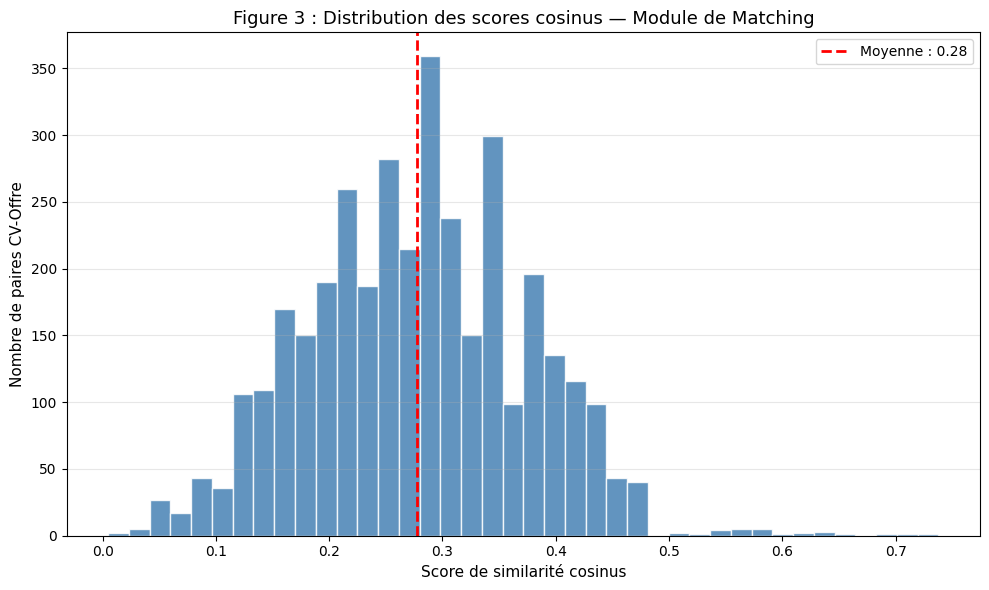

✅ Distribution des scores cosinus sauvegardée !


In [ ]:
# ── FIGURE 3 : Distribution des scores cosinus — Matching ──
import matplotlib.pyplot as plt
import numpy as np
from sentence_transformers import SentenceTransformer, util
import pandas as pd

# Charger modèle et jobs
model_sbert = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
df_jobs = pd.read_csv("/content/drive/MyDrive/ResumeProject/jobs_dataset.csv")

# Calculer scores cosinus sur un échantillon de CVs
sample_cvs = df['Resume_Cleaned'].sample(50, random_state=42).tolist()
job_descriptions = df_jobs['Job_Description'].tolist()

all_scores = []
cv_vecs = model_sbert.encode(sample_cvs, convert_to_tensor=True)
job_vecs = model_sbert.encode(job_descriptions, convert_to_tensor=True)

for cv_vec in cv_vecs:
    scores = util.cos_sim(cv_vec, job_vecs)[0].cpu().numpy()
    all_scores.extend(scores.tolist())

# Tracer l'histogramme
plt.figure(figsize=(10, 6))
plt.hist(all_scores, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(all_scores), color='red', linestyle='--',
            linewidth=2, label=f'Moyenne : {np.mean(all_scores):.2f}')
plt.title('Figure 3 : Distribution des scores cosinus — Module de Matching', fontsize=13)
plt.xlabel('Score de similarité cosinus', fontsize=11)
plt.ylabel('Nombre de paires CV-Offre', fontsize=11)
plt.legend(fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ResumeProject/distribution_cosinus.pdf', dpi=150)
plt.show()
print("✅ Distribution des scores cosinus sauvegardée !")